# Chapter4：最適化問題入門

学べること
- [基本]　if文 や for文などの基本的な構文を活用して単純作業をコンピュータにお願いできるようになる
- [基本]　断片的に作成したコードを要件に合わせて関数としてプログラムできるようになる
- [発展]　動的計画法による効率的なアルゴリズムを実装できるようになる

# 🧑‍🚀宇宙船の航路計画

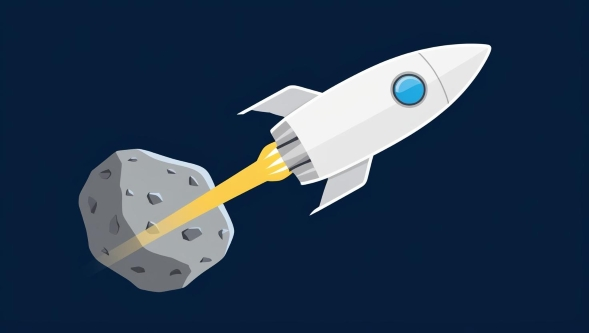

あなたは宇宙船の船長。

宇宙連合からの指令で、複数の惑星をすべて訪れて現地住民との外交を行い、
出発点に戻るミッションに挑みます。

しかし、いかに宇宙連合の宇宙船といえど、惑星間の移動にはかなり時間がかかります。

そこで優秀な船長であるあなたがやるべき仕事は、**総移動時間を最小化する最適な航路** を見つけることです。

## 🚀問題1 : 小規模な惑星間移動 [基本]

火山惑星, 氷の惑星, 密林惑星, 超重力惑星の4つの惑星を巡っていきます。

このときの移動にかかる日数の行列 (4×4) は以下の通りです：

|     |  火山惑星  |  氷の惑星  |  密林惑星  |  超重力惑星  |
| :-: | :-: | :-: | :-: | :-: |
|  火山惑星  |  0  | 12  | 13  | 53  |
|  氷の惑星  | 10  |  0  | 35  | 61  |
|  密林惑星  | 15  | 35  |  0  | 75  |
|  超重力惑星  | 50  | 65  | 80  |  0  |

- $i$ 行 $j$ 列目の値は $i→j$ の移動にかかる日数を表します
- $i→i$ にかかる日数は 0

火山惑星から出発してすべての惑星をちょうど一度ずつ訪問し、

出発点に戻るのにかかる**総移動日数の最小値**と**その航路**を求めましょう。

### 🔴課題1-1

- 火山惑星から始まり、火山惑星で終わる全ての航路を**手書き**で列挙してください。
- それぞれの航路に対して総移動日数を**手作業で**計算してください。
- **総移動日数の最小値**と**その航路**を答えてください。

### ⚪️回答欄1-1

このマークダウンセルに回答を書いてください。

全ての航路は

1. 
2. 
3. 
4. 
5. 
6. 

- 総移動日数の最小値は、「　　　　」日
- 総移動日数が最小となる航路は、「　　　　」です。


### 🔵解答例・解説 1-1

航路, 総移動日数

- 火山惑星 → 氷の惑星 → 密林惑星 → 超重力惑星 → 火山惑星, 172日
- 火山惑星 → 氷の惑星 → 超重力惑星 → 密林惑星 → 火山惑星, 168日
- 火山惑星 → 密林惑星 → 氷の惑星 → 超重力惑星 → 火山惑星, 159日
- 火山惑星 → 超重力惑星 → 氷の惑星 → 密林惑星 → 火山惑星, 163日
- 火山惑星 → 密林惑星 → 超重力惑星 → 氷の惑星 → 火山惑星, 168日
- 火山惑星 → 超重力惑星 → 密林惑星 → 氷の惑星 → 火山惑星, 178日

出発点を固定しているので、惑星が 4 つの場合は $(4-1)!$、つまり 6 通りの航路があります。

それぞれの総移動日数を比較すると、最小値は「159日」で、

その航路は　火山惑星 → 密林惑星 → 氷の惑星 → 超重力惑星 → 火山惑星　です。

### 🔴課題1-2

- 火山惑星から始まり、火山惑星で終わる全ての航路をプログラムを書いて列挙してください。
- それぞれの航路に対して総移動日数をプログラムを書いて計算してください。
- **総移動日数の最小値**と**その航路**をプログラムを書いて答えてください。

ヒント：列挙にはループ処理(for文)を使います。書き方は以下のページを参照。

- [4. その他の制御フローツール — Python 3.13.2 ドキュメント](https://docs.python.org/ja/3/tutorial/controlflow.html#for-statements)
- [Python for文まとめ #Python3 - Qiita](https://qiita.com/MoroeTachibana-oh/items/b3afbd952db3aee10ef7)

### ⚪️回答欄1-2

In [ ]:
# 全ての航路を列挙して print する













In [ ]:
# それぞれの航路に対して総移動日数を計算して print する













In [ ]:
# 総移動日数の最小値とその航路を print する













### 🔵解答例・解説 1-2

Python には組み合わせを全列挙するのに便利なツールとして `itertools` というものが最初から組み込まれています。

今回はそれを用いて航路の順列を全列挙しましょう。

- [itertools --- 効率的なループ用のイテレータ生成関数群 — Python 3.13.2 ドキュメント](https://docs.python.org/ja/3.13/library/itertools.html#itertools.permutations)
- [Pythonで競プロをやる時にそこそこ使う書き方（itertools編） #Python3 - Qiita](https://qiita.com/uni745e/items/9823ce5cd9c279a12d8a)

In [1]:
import itertools

planets = ["火山惑星", "氷の惑星", "密林惑星", "超重力惑星"]
start = "火山惑星"
goal = "火山惑星"
other_planets = ["氷の惑星", "密林惑星", "超重力惑星"] # 出発点と終着点を除く惑星のリスト

# 他の惑星の訪問順序をすべて列挙して出発点と終着点を加える
for perm in itertools.permutations(other_planets):
    route = [start] + list(perm) + [goal]
    print(route)

['火山惑星', '氷の惑星', '密林惑星', '超重力惑星', '火山惑星']
['火山惑星', '氷の惑星', '超重力惑星', '密林惑星', '火山惑星']
['火山惑星', '密林惑星', '氷の惑星', '超重力惑星', '火山惑星']
['火山惑星', '密林惑星', '超重力惑星', '氷の惑星', '火山惑星']
['火山惑星', '超重力惑星', '氷の惑星', '密林惑星', '火山惑星']
['火山惑星', '超重力惑星', '密林惑星', '氷の惑星', '火山惑星']


次にコストを計算するプログラムを書きましょう。

まずは、['火山惑星', '氷の惑星', '密林惑星', '超重力惑星', '火山惑星'] のコスト総移動日数を計算するプログラムを書きます。

In [2]:
cost_matrix_4x4 = [
        [0, 12, 13, 53],
        [10, 0, 35, 61],
        [15, 35, 0, 75],
        [50, 65, 80, 0]
    ]

# インデックスに対応付けて ['火山惑星', '氷の惑星', '密林惑星', '超重力惑星', '火山惑星'] を表す
route_1 = [0, 1, 2, 3, 0]

total_cost = 0 # 総移動日数を初期化
for i in range(len(route_1) - 1):
    total_cost += cost_matrix_4x4[route_1[i]][route_1[i+1]] # i → i+1 の移動日数を総移動日数に加える

print(f"['火山惑星', '氷の惑星', '密林惑星', '超重力惑星', '火山惑星'] の総移動日数は {total_cost}")

['火山惑星', '氷の惑星', '密林惑星', '超重力惑星', '火山惑星'] の総移動日数は 172


ほかのルートについて総移動日数を計算できるようなプログラムを書きます。

In [3]:
cost_matrix_4x4 = [
        [0, 12, 13, 53],
        [10, 0, 35, 61],
        [15, 35, 0, 75],
        [50, 65, 80, 0]
    ]

# 惑星名をコスト行列のインデックスに対応付けて数字で表す
# 0 : '火山惑星', 1 : '氷の惑星', 2 : '密林惑星', 3 : '超重力惑星'
planets = [0, 1, 2, 3]
start = [0]
goal = [0]
other_planets = [1, 2, 3]

# 他の惑星の訪問順序をすべて列挙
for perm in itertools.permutations(other_planets):
    route = start + list(perm) + goal
    # 総移動日数を計算
    total_cost = 0
    for i in range(len(route) - 1):
        total_cost += cost_matrix_4x4[route[i]][route[i+1]]
    
    print(f"航路 {route} の総移動日数は {total_cost}")

航路 [0, 1, 2, 3, 0] の総移動日数は 172
航路 [0, 1, 3, 2, 0] の総移動日数は 168
航路 [0, 2, 1, 3, 0] の総移動日数は 159
航路 [0, 2, 3, 1, 0] の総移動日数は 163
航路 [0, 3, 1, 2, 0] の総移動日数は 168
航路 [0, 3, 2, 1, 0] の総移動日数は 178


総移動日数の最小値とその航路を print できるようにします

In [4]:
cost_matrix_4x4 = [
        [0, 12, 13, 53],
        [10, 0, 35, 61],
        [15, 35, 0, 75],
        [50, 65, 80, 0]
    ]

# 惑星名をコスト行列のインデックスに対応付けて数字で表す
# 0 : '火山惑星', 1 : '氷の惑星', 2 : '密林惑星', 3 : '超重力惑星'
planets = [0, 1, 2, 3]
start = [0]
goal = [0]
other_planets = [1, 2, 3]

# 総移動日数の最小値とその航路を代入する変数を初期化
min_cost = float('inf') # 無限大で初期化しておく
best_route = None

# 他の惑星の訪問順序をすべて列挙
for perm in itertools.permutations(other_planets):
    route = start + list(perm) + goal

    # 総移動日数を計算
    total_cost = 0
    for i in range(len(route) - 1):
        total_cost += cost_matrix_4x4[route[i]][route[i+1]]
    
    # 最小コストの更新
    if total_cost < min_cost:
        min_cost = total_cost
        best_route = route
    
print(f"総移動日数の最小値は {min_cost} 日で、その航路は {best_route} ")    

総移動日数の最小値は 159 日で、その航路は [0, 2, 1, 3, 0] 


惑星名を数字に対応付けてしまったので航路がわかりにくいですね。

数字をもとの惑星名に戻すプログラムも追加すると以下のようになります。

In [5]:
cost_matrix_4x4 = [
        [0, 12, 13, 53],
        [10, 0, 35, 61],
        [15, 35, 0, 75],
        [50, 65, 80, 0]
    ]

# 惑星名をコスト行列のインデックスに対応付けて数字で表す
# 0 : '火山惑星', 1 : '氷の惑星', 2 : '密林惑星', 3 : '超重力惑星'
planets = [0, 1, 2, 3]
start = [0]
goal = [0]
other_planets = [1, 2, 3]

# 総移動日数の最小値とその航路を代入する変数を初期化
min_cost = float('inf') # 無限大で初期化しておく
best_route = None

# 他の惑星の訪問順序をすべて列挙
for perm in itertools.permutations(other_planets):
    route = start + list(perm) + goal

    # 総移動日数を計算
    total_cost = 0
    for i in range(len(route) - 1):
        total_cost += cost_matrix_4x4[route[i]][route[i+1]]
    
    # 最小コストの更新
    if total_cost < min_cost:
        min_cost = total_cost
        best_route = route

# 惑星インデックス -> 惑星名
planet_names = {
    0: "火山惑星",
    1: "氷の惑星",
    2: "密林惑星",
    3: "超重力惑星"
}

# 数字で表された route を惑星名リストに変換
named_best_route = [planet_names[i] for i in best_route]
    
print(f"総移動日数の最小値は {min_cost} 日で、その航路は {named_best_route} ")    

総移動日数の最小値は 159 日で、その航路は ['火山惑星', '密林惑星', '氷の惑星', '超重力惑星', '火山惑星'] 


これで課題 1-2 で作成すべきプログラムができました。
お疲れ様です。

### 🔴課題1-3

ここまで作成したプログラムを宇宙連合のほかの船長も利用できるようにしてください。

具体的には以下の要件を満たすような関数を作ってください。

- 入力：
  - コスト行列 $C \in \mathbb{R}^{n\times n}$
  - 惑星名とコスト行列のインデックスが対応した辞書
  - 出発地
  - 到着地
- 出力：
  - 総移動日数の最小値
  - 総移動日数が最小となる航路


### ⚪️回答欄1-3

In [ ]:
def solve_opt_route(cost_matrix, planet_names, start=0, goal=0):
    """
    cost_matrix: 2次元リスト（コスト行列）
    planet_names: 惑星名とコスト行列のインデックスが対応した辞書
    start: 出発惑星（インデックス）
    goal: 到着惑星（インデックス）
    """
    # この関数を穴埋めするように実装してもよいですし、
    # 全部消してオリジナルで実装しても構いません
















    return min_cost, best_route

# 作成した関数を呼び出す main 
if __name__ == "__main__":
    # 惑星インデックス -> 惑星名
    planet_names = {
        0: "火山惑星",
        1: "氷の惑星",
        2: "密林惑星",
        3: "超重力惑星"
    }

    cost_matrix_4x4 = [
        [0, 12, 13, 53],
        [10, 0, 35, 61],
        [15, 35, 0, 75],
        [50, 65, 80, 0]
    ]
    
    cost, route = solve_opt_route(cost_matrix_4x4, planet_names, start=0, goal=0)

    print(f"答え")
    print(f"最小日数: {cost}")
    print(f"最適経路: {route}")

### 🔵解答例・解説 1-3

In [6]:
import itertools

def brute_force_tsp(cost_matrix, planet_names, start=0, goal=0):
    """
    cost_matrix: 2次元リスト（コスト行列）
    planet_names: 惑星名とコスト行列のインデックスが対応した辞書
    start: 出発惑星（インデックス）
    goal: 到着惑星（インデックス）
    """
    n = len(cost_matrix)
    planets = list(range(n))
    
    # 出発点を除く惑星のリストを生成
    other_planets = [p for p in planets if p != start]
    
    min_cost = float('inf')
    best_route = None

    # 他の惑星の訪問順序をすべて列挙
    for perm in itertools.permutations(other_planets):
        # start -> ... -> goal の巡回ルートを考える
        route = [start] + list(perm) + [goal]
        
        # コストを計算
        cost = 0
        for i in range(len(route) - 1):
            cost += cost_matrix[route[i]][route[i+1]]
        
        # 最小コストの更新
        if cost < min_cost:
            min_cost = cost
            best_route = route

    # 数字で表された route を惑星名リストに変換
    named_route = [planet_names[i] for i in best_route]
    
    return min_cost, named_route

if __name__ == "__main__":
    # 惑星インデックス -> 惑星名
    planet_names = {
        0: "火山惑星",
        1: "氷の惑星",
        2: "密林惑星",
        3: "超重力惑星"
    }

    cost_matrix_4x4 = [
        [0, 12, 13, 53],
        [10, 0, 35, 61],
        [15, 35, 0, 75],
        [50, 65, 80, 0]
    ]
    
    cost, route = brute_force_tsp(cost_matrix_4x4, planet_names, start=0, goal=0)

    print(f"答え")
    print(f"最小日数: {cost}")
    print(f"最適経路: {route}")


答え
最小日数: 159
最適経路: ['火山惑星', '密林惑星', '氷の惑星', '超重力惑星', '火山惑星']


無事に関数として完成しました！これからはこの関数を使うだけで簡単に最適な航路を求められますね！🥳

## 💡問題1の解説

この問題にはさまざまな解法がありますが、もっとも単純な方法はここまでで実装した**考えられるすべてのルートを列挙してそれぞれのコストを計算・比較する方法**です。

これは**力まかせ探索**（[*Brute force*](https://ja.wikipedia.org/wiki/%E5%8A%9B%E3%81%BE%E3%81%8B%E3%81%9B%E6%8E%A2%E7%B4%A2)）と呼ばれます。

出発点を固定しているので、惑星が 4 つの場合は $(4-1)!$、つまり 6 通りしかありません。

これくらいの規模なら、しらみつぶしに計算しても問題ないですね。

ただし、惑星数を $n$ とすると、単純な全探索は $(n-1)!$ 通り（出発点固定）になり、$n$ が大きくなると**爆発的**に増えてしまいます。

そこで、惑星数が多い問題では、もう少し工夫した解法を考える必要がでてきます。


## 🌌問題2：大規模な惑星間移動 [発展]

宇宙連合はさらに規模の大きな任務をあなたに与えました。
今度は以下の13個の惑星を訪れ、外交任務を完了させなければなりません。

- 火山惑星🌋
- 氷の惑星🧊
- 密林惑星🌳
- 超重力惑星🪐
- 砂漠惑星🌵
- 海洋惑星🌊
- 岩石惑星🗿
- ガス惑星☁️
- 放射能惑星🩻
- 磁気嵐惑星🌪
- 結晶惑星💎
- 深海惑星🐋
- 巨大植物惑星🌾

惑星間の移動にかかる日数をまとめた行列（13×13）は次の通りです：

|              | 火山 | 氷   | 密林 | 超重力 | 砂漠 | 海洋 | 岩石 | ガス | 放射能 | 磁気嵐 | 結晶 | 深海 | 巨大植物 |
|--------------|:--------:|:--------:|:--------:|:----------:|:--------:|:--------:|:--------:|:--------:|:----------:|:----------:|:--------:|:--------:|:------------:|
| 火山     | 0        | 12       | 10       | 19         | 8        | 15       | 21       | 25       | 17         | 14         | 17       | 16       | 18           |
| 氷       | 12       | 0        | 9        | 18         | 20       | 13       | 17       | 23       | 11         | 10         | 15       | 14       | 14           |
| 密林     | 10       | 9        | 0        | 20         | 25       | 16       | 18       | 30       | 14         | 7          | 13       | 12       | 11           |
| 超重力   | 19       | 18       | 20       | 0          | 22       | 14       | 24       | 16       | 27         | 20         | 23       | 26       | 24           |
| 砂漠     | 8        | 20       | 25       | 22         | 0        | 9        | 20       | 22       | 12         | 12         | 11       | 10       | 13           |
| 海洋     | 15       | 13       | 16       | 14         | 9        | 0        | 8        | 19       | 21         | 18         | 14       | 17       | 17           |
| 岩石     | 21       | 17       | 18       | 24         | 20       | 8        | 0        | 12       | 23         | 22         | 20       | 19       | 20           |
| ガス     | 25       | 23       | 30       | 16         | 22       | 19       | 12       | 0        | 15         | 26         | 18       | 22       | 19           |
| 放射能   | 17       | 11       | 14       | 27         | 12       | 21       | 23       | 15       | 0          | 16         | 12       | 14       | 15           |
| 磁気嵐   | 14       | 10       | 7        | 20         | 12       | 18       | 22       | 26       | 16         | 0          | 9        | 13       | 12           |
| 結晶     | 17       | 15       | 13       | 23         | 11       | 14       | 20       | 18       | 12         | 9          | 0        | 10       | 16           |
| 深海     | 16       | 14       | 12       | 26         | 10       | 17       | 19       | 22       | 14         | 13         | 10       | 0        | 15           |
| 巨大植物 | 18       | 14       | 11       | 24         | 13       | 17       | 20       | 19       | 15         | 12         | 16       | 15       | 0            |

- 惑星間の移動日数は双方向で同じです（対称行列）
- 出発点（火山惑星）を起点として、全ての惑星をちょうど1度ずつ訪問し、再び火山惑星へ戻ります。

惑星数が13個になると、可能な巡回ルートの数は $(13-1)! = 479,001,600$ 通りにもなります。
これは力まかせ探索（ブルートフォース）では計算時間が結構かかります。

これが、14,15..., と増えていくと計算時間が途方もなくなっていきます。

そこであなたがこなすべき任務は、**より効率的なアルゴリズムを設計して、総移動日数が最小となる航路を見つけることです。**

### 🔴課題2-1

- 先ほど実装した関数を使って 13 個の惑星のコスト行列に対して総移動日数の最小値とその航路を計算してみましょう

### ⚪️回答欄2-1

In [ ]:
if __name__ == "__main__":
    # 惑星インデックス -> 惑星名
    planet_names_13 = {
        0: "火山惑星",
        1: "氷の惑星",
        2: "密林惑星",
        3: "超重力惑星",
        4: "砂漠惑星",
        5: "海洋惑星",
        6: "岩石惑星",
        7: "ガス惑星",
        8: "放射能惑星",
        9: "磁気嵐惑星",
        10: "結晶惑星",
        11: "深海惑星",
        12: "巨大植物惑星"
    }
    
    cost_matrix_13x13 = [
        [0, 12, 10, 19, 8, 15, 21, 25, 17, 14, 17, 16, 18],
        [12, 0, 9, 18, 20, 13, 17, 23, 11, 10, 15, 14, 14],
        [10, 9, 0, 20, 25, 16, 18, 30, 14, 7, 13, 12, 11],
        [19, 18, 20, 0, 22, 14, 24, 16, 27, 20, 23, 26, 24],
        [8, 20, 25, 22, 0, 9, 20, 22, 12, 12, 11, 10, 13],
        [15, 13, 16, 14, 9, 0, 8, 19, 21, 18, 14, 17, 17],
        [21, 17, 18, 24, 20, 8, 0, 12, 23, 22, 20, 19, 20],
        [25, 23, 30, 16, 22, 19, 12, 0, 15, 26, 18, 22, 19],
        [17, 11, 14, 27, 12, 21, 23, 15, 0, 16, 12, 14, 15],
        [14, 10, 7, 20, 12, 18, 22, 26, 16, 0, 9, 13, 12],
        [17, 15, 13, 23, 11, 14, 20, 18, 12, 9, 0, 10, 16],
        [16, 14, 12, 26, 10, 17, 19, 22, 14, 13, 10, 0, 15],
        [18, 14, 11, 24, 13, 17, 20, 19, 15, 12, 16, 15, 0]
    ]
    
    cost, route = solve_opt_route(cost_matrix_13x13, planet_names_13, start=0, goal=0)

    print(f"答え")
    print(f"最小日数: {cost}")
    print(f"最適経路: {route}")

### 🔵解答例・解説 2-1

※ `tqdm` と `time` モジュールを使ってプログレスバー表示と実行時間の測定をできるようにしたので、少しコードを変更していますが、やっていることは問題1で作成した関数と同じです。

In [8]:
import itertools
import time
from tqdm import tqdm
import math

def brute_force_tsp_tqdm(cost_matrix, planet_names, start=0, goal=0):
    """
    cost_matrix: 2次元リスト（コスト行列）
    planet_names: 惑星名とコスト行列のインデックスが対応した辞書
    start: 出発惑星（インデックス）
    goal: 到着惑星（インデックス）
    """
    start_time = time.time()

    n = len(cost_matrix)
    planets = list(range(n))
    
    # 出発点と到着点を除く惑星のリストを生成
    other_planets = [p for p in planets if p != start and p != goal]
    num_other_planets = len(other_planets)
    total_permutations = math.factorial(num_other_planets) if num_other_planets > 0 else 1 # 順列の総数を計算 (惑星数が2つ以下の場合に備えて1にする)

    min_cost = float('inf')
    best_route = None

    # 他の惑星の訪問順序をすべて列挙
    with tqdm(itertools.permutations(other_planets), total=total_permutations) as pbar:
        for perm in pbar:
            # start -> ... -> goal の巡回ルートを考える
            route = [start] + list(perm) + [goal]
            
            # コストを計算
            cost = 0
            for i in range(len(route) - 1):
                cost += cost_matrix[route[i]][route[i+1]]
            
            # 最小コストの更新
            if cost < min_cost:
                min_cost = cost
                best_route = route

    # 数字で表された route を惑星名リストに変換
    named_route = [planet_names[i] for i in best_route]
    
    end_time = time.time()
    execution_time = end_time - start_time

    return min_cost, named_route, execution_time

if __name__ == "__main__":
    planet_names_13 = {
        0: "火山惑星",
        1: "氷の惑星",
        2: "密林惑星",
        3: "超重力惑星",
        4: "砂漠惑星",
        5: "海洋惑星",
        6: "岩石惑星",
        7: "ガス惑星",
        8: "放射能惑星",
        9: "磁気嵐惑星",
        10: "結晶惑星",
        11: "深海惑星",
        12: "巨大植物惑星"
    }

    cost_matrix_13x13 = [
            [0, 12, 10, 19, 8, 15, 21, 25, 17, 14, 17, 16, 18],
            [12, 0, 9, 18, 20, 13, 17, 23, 11, 10, 15, 14, 14],
            [10, 9, 0, 20, 25, 16, 18, 30, 14, 7, 13, 12, 11],
            [19, 18, 20, 0, 22, 14, 24, 16, 27, 20, 23, 26, 24],
            [8, 20, 25, 22, 0, 9, 20, 22, 12, 12, 11, 10, 13],
            [15, 13, 16, 14, 9, 0, 8, 19, 21, 18, 14, 17, 17],
            [21, 17, 18, 24, 20, 8, 0, 12, 23, 22, 20, 19, 20],
            [25, 23, 30, 16, 22, 19, 12, 0, 15, 26, 18, 22, 19],
            [17, 11, 14, 27, 12, 21, 23, 15, 0, 16, 12, 14, 15],
            [14, 10, 7, 20, 12, 18, 22, 26, 16, 0, 9, 13, 12],
            [17, 15, 13, 23, 11, 14, 20, 18, 12, 9, 0, 10, 16],
            [16, 14, 12, 26, 10, 17, 19, 22, 14, 13, 10, 0, 15],
            [18, 14, 11, 24, 13, 17, 20, 19, 15, 12, 16, 15, 0]
        ]
    cost, route, execution_time = brute_force_tsp_tqdm(cost_matrix_13x13, planet_names_13, start=0, goal=0)

    print(f"答え")
    print(f"最小日数: {cost}")
    print(f"最適経路: {route}")
    print(f"実行時間: {execution_time:.2f}秒")

  0%|          | 0/479001600 [00:00<?, ?it/s]

100%|██████████| 479001600/479001600 [06:35<00:00, 1212443.26it/s]

答え
最小日数: 148
最適経路: ['火山惑星', '密林惑星', '磁気嵐惑星', '結晶惑星', '深海惑星', '巨大植物惑星', '放射能惑星', '氷の惑星', '超重力惑星', 'ガス惑星', '岩石惑星', '海洋惑星', '砂漠惑星', '火山惑星']
実行時間: 395.07秒


まぁ、遅いですね。

### 🔴課題2-2

- 総移動日数を最小化するための効率的なアルゴリズムを考えて、実装してください。
- そのアルゴリズムを用いて、最小の総移動日数とそのときの航路を求めてください。

ヒント：
- 例えば、**動的計画法**が効率的なアルゴリズムとして実装できると思います。
- 「ビットマスク」「TSP」「動的計画法」「巡回セールスマン問題」などのキーワードでググって実装してください。
- ChatGPT や Claude, Gemini などの LLM を使って理解して実装しても良いです。


In [ ]:
def solve_efficient_opt_route(cost_matrix, planet_names, start=0, goal=0):
    """
    cost_matrix: 2次元リスト（コスト行列）
    planet_names: 惑星名とコスト行列のインデックスが対応した辞書
    start: 出発惑星（インデックス）
    goal: 到着惑星（インデックス）
    """
    # この関数を穴埋めするように実装してもよいですし、
    # 全部消してオリジナルで実装しても構いません

















    


if __name__ == "__main__":
    # 惑星インデックス -> 惑星名
    planet_names = {
        0: "火山惑星",
        1: "氷の惑星",
        2: "密林惑星",
        3: "超重力惑星",
        4: "砂漠惑星",
        5: "海洋惑星",
        6: "岩石惑星",
        7: "ガス惑星",
        8: "放射能惑星",
        9: "磁気嵐惑星",
        10: "結晶惑星",
        11: "深海惑星",
        12: "巨大植物惑星"
    }
    
    cost_matrix = [
        [0, 12, 10, 19, 8, 15, 21, 25, 17, 14, 17, 16, 18],
        [12, 0, 9, 18, 20, 13, 17, 23, 11, 10, 15, 14, 14],
        [10, 9, 0, 20, 25, 16, 18, 30, 14, 7, 13, 12, 11],
        [19, 18, 20, 0, 22, 14, 24, 16, 27, 20, 23, 26, 24],
        [8, 20, 25, 22, 0, 9, 20, 22, 12, 12, 11, 10, 13],
        [15, 13, 16, 14, 9, 0, 8, 19, 21, 18, 14, 17, 17],
        [21, 17, 18, 24, 20, 8, 0, 12, 23, 22, 20, 19, 20],
        [25, 23, 30, 16, 22, 19, 12, 0, 15, 26, 18, 22, 19],
        [17, 11, 14, 27, 12, 21, 23, 15, 0, 16, 12, 14, 15],
        [14, 10, 7, 20, 12, 18, 22, 26, 16, 0, 9, 13, 12],
        [17, 15, 13, 23, 11, 14, 20, 18, 12, 9, 0, 10, 16],
        [16, 14, 12, 26, 10, 17, 19, 22, 14, 13, 10, 0, 15],
        [18, 14, 11, 24, 13, 17, 20, 19, 15, 12, 16, 15, 0]
    ]
    
    cost, route = solve_efficient_opt_route(cost_matrix, planet_names, start=0, goal=0)

    print(f"答え")
    print(f"最小日数: {cost}")
    print(f"最適経路: {route}")

### 🔵解答例・解説 2-2

In [9]:
def dp_tsp(cost_matrix, planet_names, start=0,  goal=0):
    n = len(cost_matrix)  # 惑星の数を取得
    all_sets = {}  # 各状態の最適解を保存するための辞書

    def dp(mask, pos):
        if mask == (1 << n) - 1:  # 全ての惑星を訪問済みの場合
            return cost_matrix[pos][goal], [goal]  # goal に戻るコストを返す
        if (mask, pos) in all_sets:  # 既に計算した状態なら再利用
            return all_sets[(mask, pos)]

        min_cost = float('inf')  # 最小コストを無限大で初期化
        min_path = []  # 最小コストのルートを保存するリスト
        for city in range(n):  # すべての惑星について
            if mask & (1 << city) == 0:  # まだ訪れていない惑星なら
                cost, path = dp(mask | (1 << city), city)  # 次の惑星へ移動した状態を再帰的に計算
                cost += cost_matrix[pos][city]  # 現在位置から次の惑星へのコストを追加
                if cost < min_cost:  # コストが最小なら更新
                    min_cost = cost
                    min_path = [city] + path
        
        all_sets[(mask, pos)] = (min_cost, min_path)  # 最適解を記録
        return all_sets[(mask, pos)]

    min_cost, best_route = dp(1, start)  # 出発地点から計算開始
    best_route = [0] + best_route

    # 数字で表された route を惑星名リストに変換
    best_route = [planet_names[i] for i in best_route]

    return min_cost, best_route # 最小コストと最適ルートを返す

if __name__ == "__main__":
    # 惑星インデックス -> 惑星名
    planet_names = {
        0: "火山惑星",
        1: "氷の惑星",
        2: "密林惑星",
        3: "超重力惑星",
        4: "砂漠惑星",
        5: "海洋惑星",
        6: "岩石惑星",
        7: "ガス惑星",
        8: "放射能惑星",
        9: "磁気嵐惑星",
        10: "結晶惑星",
        11: "深海惑星",
        12: "巨大植物惑星"
    }
    
    cost_matrix = [
        [0, 12, 10, 19, 8, 15, 21, 25, 17, 14, 17, 16, 18],
        [12, 0, 9, 18, 20, 13, 17, 23, 11, 10, 15, 14, 14],
        [10, 9, 0, 20, 25, 16, 18, 30, 14, 7, 13, 12, 11],
        [19, 18, 20, 0, 22, 14, 24, 16, 27, 20, 23, 26, 24],
        [8, 20, 25, 22, 0, 9, 20, 22, 12, 12, 11, 10, 13],
        [15, 13, 16, 14, 9, 0, 8, 19, 21, 18, 14, 17, 17],
        [21, 17, 18, 24, 20, 8, 0, 12, 23, 22, 20, 19, 20],
        [25, 23, 30, 16, 22, 19, 12, 0, 15, 26, 18, 22, 19],
        [17, 11, 14, 27, 12, 21, 23, 15, 0, 16, 12, 14, 15],
        [14, 10, 7, 20, 12, 18, 22, 26, 16, 0, 9, 13, 12],
        [17, 15, 13, 23, 11, 14, 20, 18, 12, 9, 0, 10, 16],
        [16, 14, 12, 26, 10, 17, 19, 22, 14, 13, 10, 0, 15],
        [18, 14, 11, 24, 13, 17, 20, 19, 15, 12, 16, 15, 0]
    ]
    
    cost, route = dp_tsp(cost_matrix, planet_names, start=0, goal=0)

    print(f"答え")
    print(f"最小日数: {cost}")
    print(f"最適経路: {route}")


答え
最小日数: 148
最適経路: ['火山惑星', '密林惑星', '磁気嵐惑星', '結晶惑星', '深海惑星', '巨大植物惑星', '放射能惑星', '氷の惑星', '超重力惑星', 'ガス惑星', '岩石惑星', '海洋惑星', '砂漠惑星', '火山惑星']


## 💡問題2の解説

このような計算量が非常に多い問題を効率よく解くために、動的計画法（DP）という手法をしばしば使います。

特に、「**ビットマスクを使った動的計画法**」は非常に効果的です。

この方法では、訪問した惑星の組み合わせを、ビット（0か1か）を並べたビット列（ビットマスク）として管理し、それぞれの組み合わせに対する最適な答えを記録しながら解を求めます。

**ビットマスクを使った動的計画法の具体的な手順**

- 訪問済みの惑星をビットマスクという二進数で表現します。例えば、3つの惑星（惑星0, 惑星1, 惑星2）を訪問した場合、「0111」のように表します（最初の惑星0が右端で、右から順番に1なら訪問済み、0なら未訪問を意味します）。
- 各ビットマスクに対して、現在どの惑星にいるかという状態を一緒に保持し、その状況での最小コストを順番に計算します。
- すべての惑星を訪問したことを示すビットマスクに到達したとき、その時点の最小コストがこの問題の最終的な答えとなります。

この方法を使うことで、すでに計算した部分問題を再利用して重複する計算を避けるため、全探索に比べて大幅に計算量を減らし、効率よく問題を解くことができます。

また、今回扱った問題は巡回セールスマン問題（TSP）として知られています。
- [巡回セールスマン問題 - Wikipedia](https://ja.wikipedia.org/wiki/%E5%B7%A1%E5%9B%9E%E3%82%BB%E3%83%BC%E3%83%AB%E3%82%B9%E3%83%9E%E3%83%B3%E5%95%8F%E9%A1%8C)